In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import functions
import pybamm
import numpy as np
from tqdm import trange
import optuna
import os
import functools

In [2]:
import jax
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())

All devices: [CudaDevice(id=0)]
Default backend: gpu


In [3]:
from FNO_vmapped import *

In [4]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [5]:
family = "GRF_Prada2013_"
id  = "8"
path = "data/spm/for_soc/"
train_data = np.load(path + "train/" + family + "22000_" + ".npz")
test_data = np.load(path + "test/" + family + "2200" + ".npz")

In [6]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["target_concentration_anode"])
test_cn = np.array(test_data["target_concentration_anode"])

train_c0 = np.array(train_data["initial_concentration_anode"])
test_c0 = np.array(test_data["initial_concentration_anode"])


cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [7]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
hidden_channels = 64
output_channels = 1
#param_channels = 50

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar


# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)


# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)
# Broadcast Ds_padded (24,) to (24, 85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
# input_tensor = jnp.stack([I_2D, c0_2D, Ds_2D], axis=-1)   # (24,85,4)
# input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels) #, param_channels=param_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
out = model.apply(params, input_tensor)
print("Input shape:", input_tensor.shape)  # should be (1,24,85,5)
print("Output shape:", out.shape)  # should be (1,24,85,1)



Input shape: (24, 85, 4)
Output shape: (24, 85, 1)


In [8]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = np.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =np.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = np.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = np.zeros((num_samples, H, W, 4))
    Y = np.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return np.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return np.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)



    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = np.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = np.tile(c0_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = np.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = np.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)


    # Stack channels: (num_samples,24,85,4)
    X = np.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)
    # X = np.stack([I_2D, c0_2D, Ds_2D], axis=-1) #Here we try to see if it works without the grid information

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = np.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [9]:
def data_loader(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    """
    A simple data loader that yields batches of preprocessed FNO data.
    
    Parameters
    ----------
    X : jnp.ndarray
        Preprocessed input data of shape (num_samples, 24,85,4).
    Y : jnp.ndarray
        Preprocessed target data of shape (num_samples, 24,85,1).
    batch_size : int
        Number of samples per batch.
    shuffle : bool
        Whether to shuffle the dataset before yielding batches.

    Yields
    ------
    (X_batch, Y_batch) : tuple of jnp.ndarray
        X_batch : (batch_size, 24,85,4)
        Y_batch : (batch_size, 24,85,1)
    """
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        batch_indices = indices[start_idx:start_idx+batch_size]
        yield X[batch_indices], Y[batch_indices]



In [10]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [11]:
def loss_fn(params, X_batch, Y_batch):
    preds = jax.vmap(model.apply, in_axes=(None, 0), out_axes=0)(params, X_batch)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [12]:
def create_cosine_schedule_with_warmup(
    warmup_steps: int,
    peak_lr: float,
    total_steps: int,
    end_lr: float = 0.0
):
    """Returns an Optax schedule: warmup -> cosine decay."""
    
    def schedule_fn(step):
        # Phase 1: Warmup
        # linearly go from 0 to peak_lr over warmup_steps
        lr = jax.lax.cond(
            step < warmup_steps,
            lambda s: peak_lr * (s / warmup_steps),
            lambda s: 0.0,
            step
        )
        
        # Phase 2: Cosine decay
        # after warmup, go from peak_lr to end_lr via half-cosine
        def decay_fn(s):
            progress = (s - warmup_steps) / float(total_steps - warmup_steps)
            # clamp progress between 0 and 1
            progress = jnp.clip(progress, 0.0, 1.0)
            cosine = 0.5 * (1.0 + jnp.cos(jnp.pi * progress))
            return end_lr + (peak_lr - end_lr) * cosine
        
        lr = jax.lax.cond(
            step >= warmup_steps,
            decay_fn,
            lambda s: lr,
            step
        )
        return lr
    
    return schedule_fn

In [13]:
# Suppose:
warmup_steps = 3667            # ~1 epoch, if 11,734 steps is an epoch
peak_lr = 8e-3                  # try bigger than your current 4e-3
total_steps = 50 * 3667      # ~293,350
end_lr = 0.5e-4                   # final LR

scheduler = create_cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

# # Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

In [14]:
optimizer = optax.adam(scheduler)
opt_state = optimizer.init(params)

In [15]:
@jax.jit
def train_step(params, opt_state, X_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch, Y_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [16]:
X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

In [17]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (88000, 24, 85, 4) dtype: float64
Y_train shape: (88000, 24, 85, 1) dtype: float64


In [18]:
num_epochs = 50
pbar = trange(num_epochs, desc="Training")

batch_size = 24

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
    
    print(f"Training Iterations per Epoch: {count}")

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training Iterations per Epoch: 3667


Epoch 1/50 | Train Loss: 0.0678 | Test Loss: 0.0374:   2%|▏         | 1/50 [01:20<1:05:23, 80.07s/it]

Training Iterations per Epoch: 3667


Epoch 2/50 | Train Loss: 0.0367 | Test Loss: 0.0179:   4%|▍         | 2/50 [02:28<58:29, 73.11s/it]  

...

Epoch 48/50 | Train Loss: 0.0007 | Test Loss: 0.0008:  96%|█████████▌| 48/50 [54:35<02:16, 68.02s/it]

Training Iterations per Epoch: 3667


Epoch 49/50 | Train Loss: 0.0007 | Test Loss: 0.0007:  98%|█████████▊| 49/50 [55:43<01:07, 68.00s/it]

Training Iterations per Epoch: 3667


Epoch 50/50 | Train Loss: 0.0007 | Test Loss: 0.0007: 100%|██████████| 50/50 [56:50<00:00, 68.22s/it]


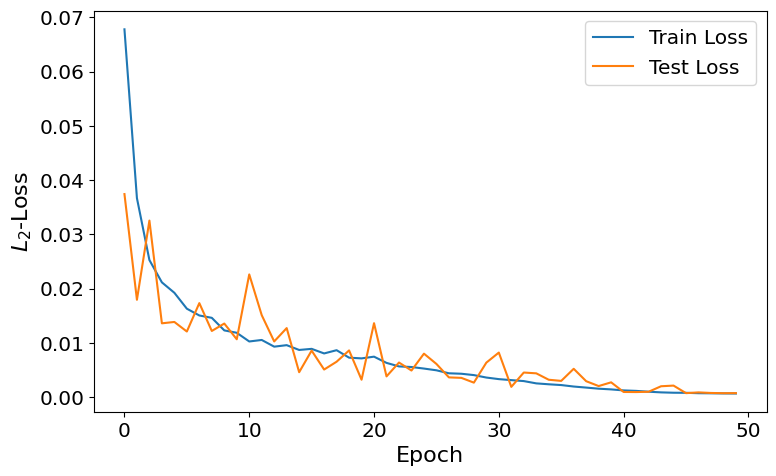

In [19]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [20]:
train_idx = np.random.randint(2, 88000)
test_idx = np.random.randint(2, 8800)

In [21]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx])

H_orig = 20
W_orig = 75
padding_r = 2
padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)


In [22]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [23]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


In [24]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


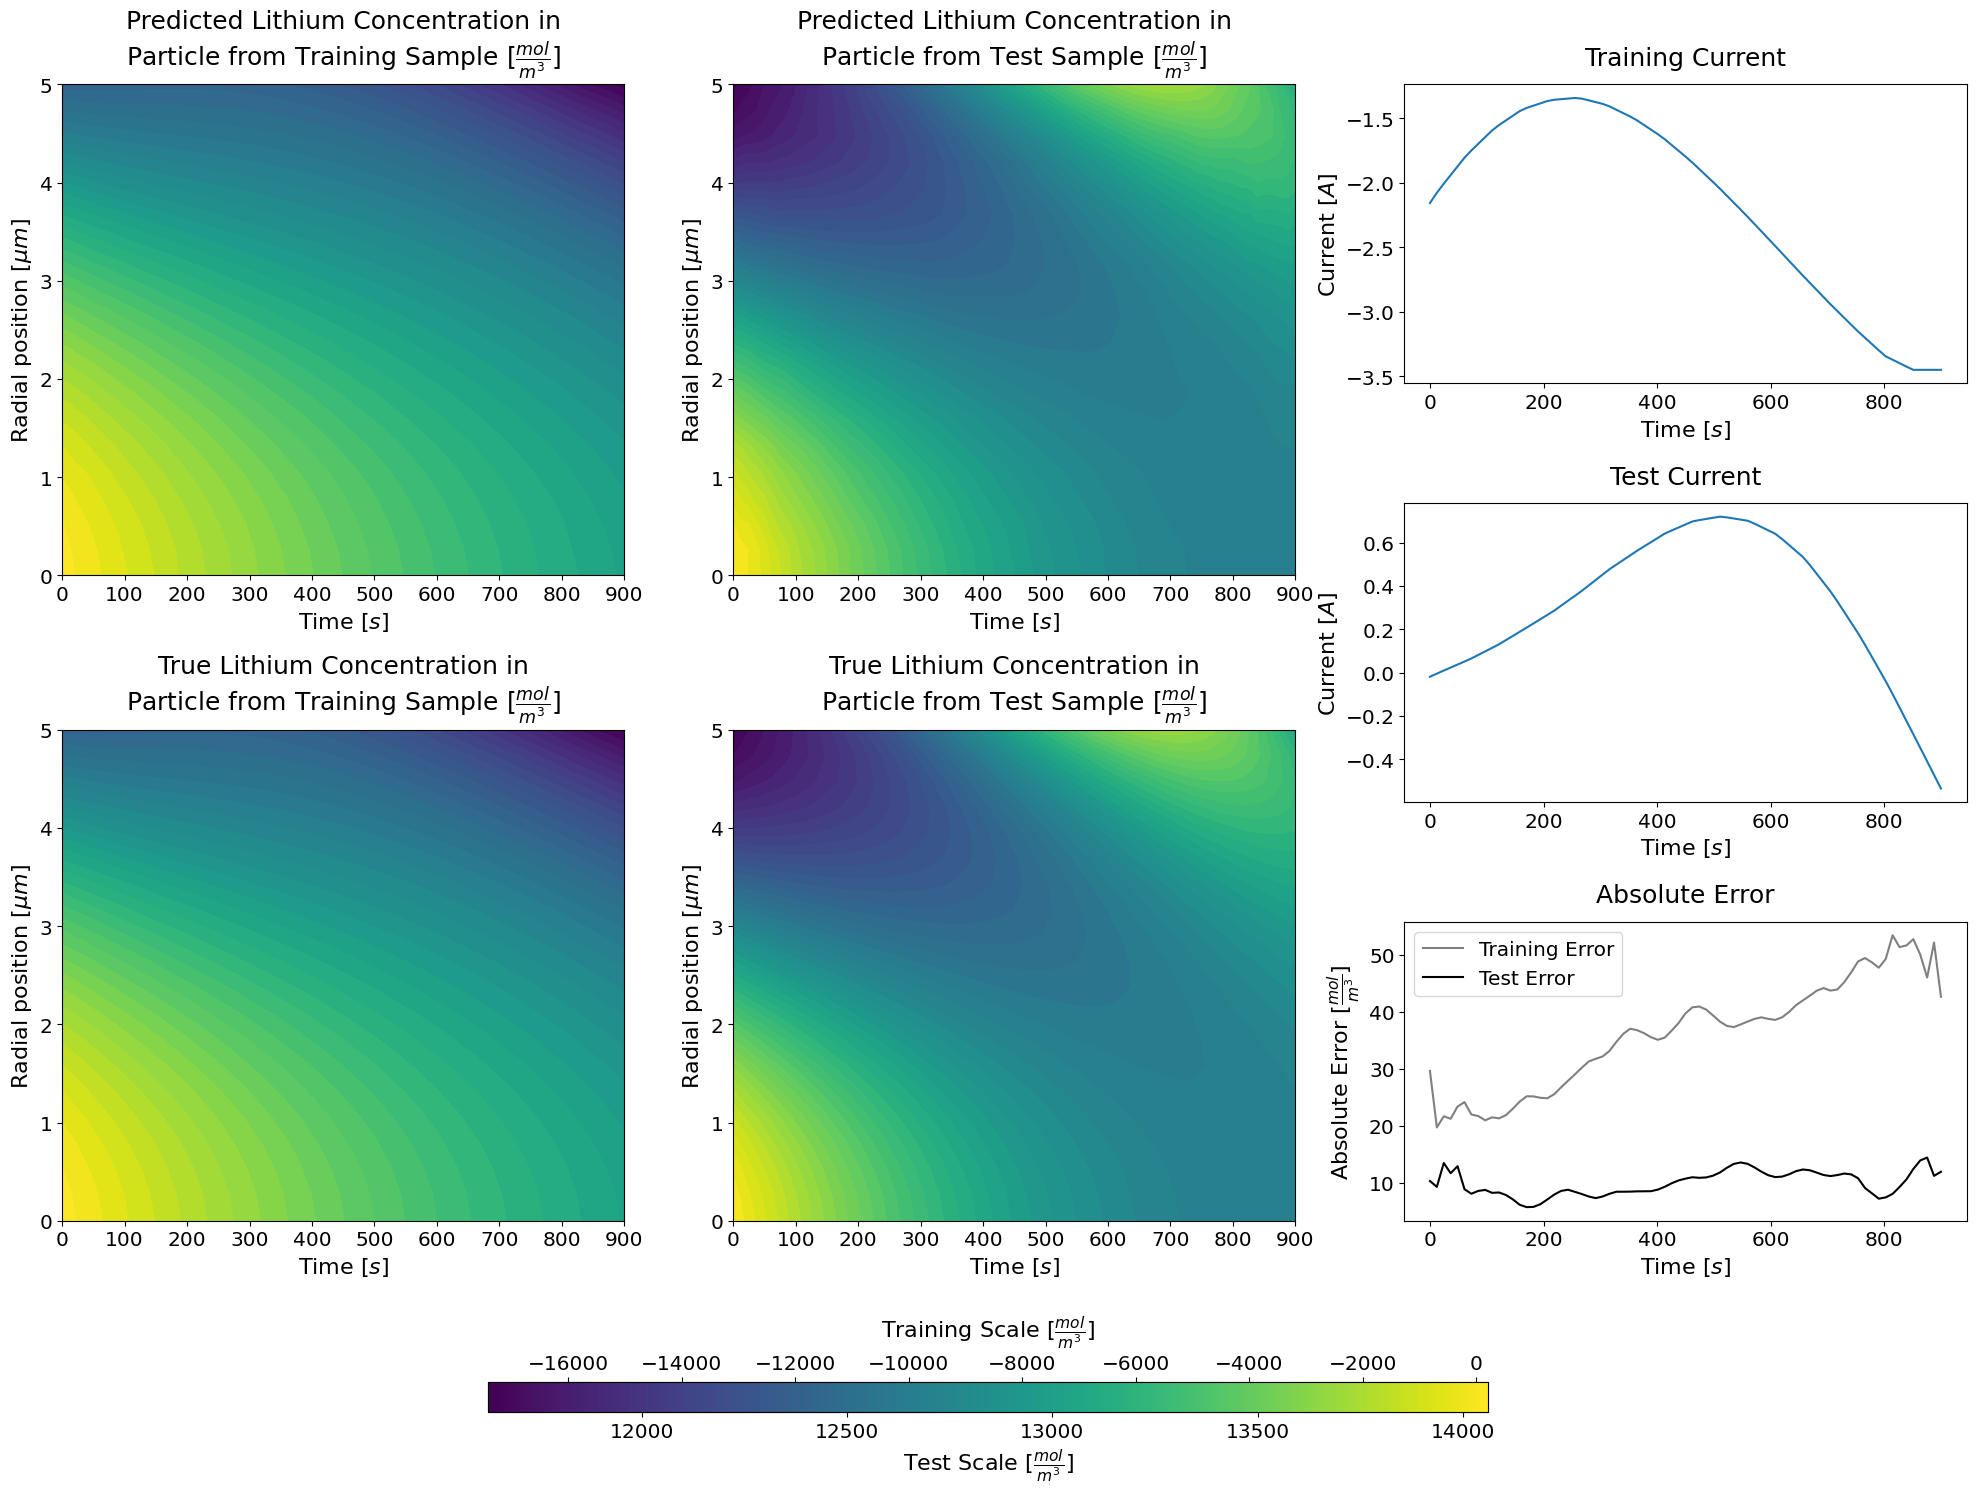

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [26]:
import os
import flax.serialization
from datetime import datetime

In [27]:
filename = functions.save_model_params(params, directory = "./trained_models/lfp/", family = family)

Saved model parameters to ./trained_models/lfp/anode_GRF_Prada2013__2025-04-08_16-03-24.msgpack


In [28]:
import gc
# del model
# del params
del X_train, Y_train, X_test, Y_test

#jax.clear_compilation_cache()
gc.collect()


6180

In [29]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["target_concentration_cathode"])
test_cn = np.array(test_data["target_concentration_cathode"])

train_c0 = np.array(train_data["initial_concentration_cathode"])
test_c0 = np.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

In [30]:
# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
out = model.apply(params, input_tensor)
print("Output shape:", out.shape)  # should be (1,24,85,1)

Output shape: (24, 85, 1)


In [31]:

optimizer = optax.adam(scheduler)
opt_state = optimizer.init(params)


In [32]:
pbar = trange(num_epochs, desc="Training")

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
    

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 50/50 | Train Loss: 0.0008 | Test Loss: 0.0009: 100%|██████████| 50/50 [56:39<00:00, 67.98s/it]


In [33]:
filename = functions.save_model_params(params, directory = "./trained_models/lfp/", prefix = "cathode", family = family)

Saved model parameters to ./trained_models/lfp/cathode_GRF_Prada2013__2025-04-08_17-00-06.msgpack


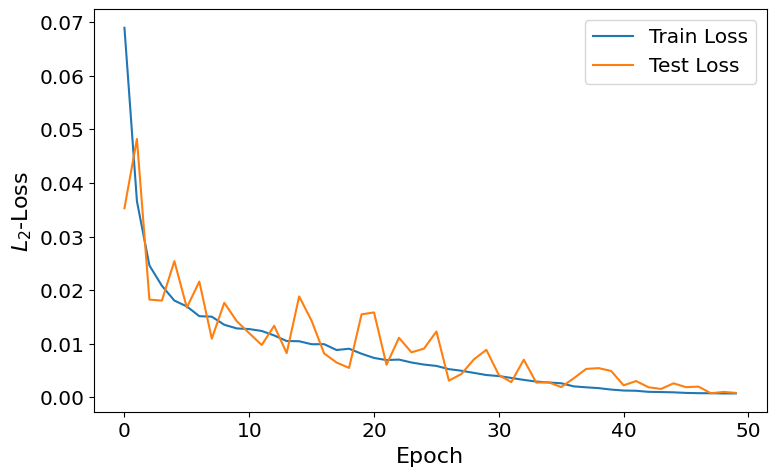

In [34]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [35]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx])

# H_orig = 20
# W_orig = 75
# padding_r = 2
# padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)

In [36]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [37]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

In [38]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


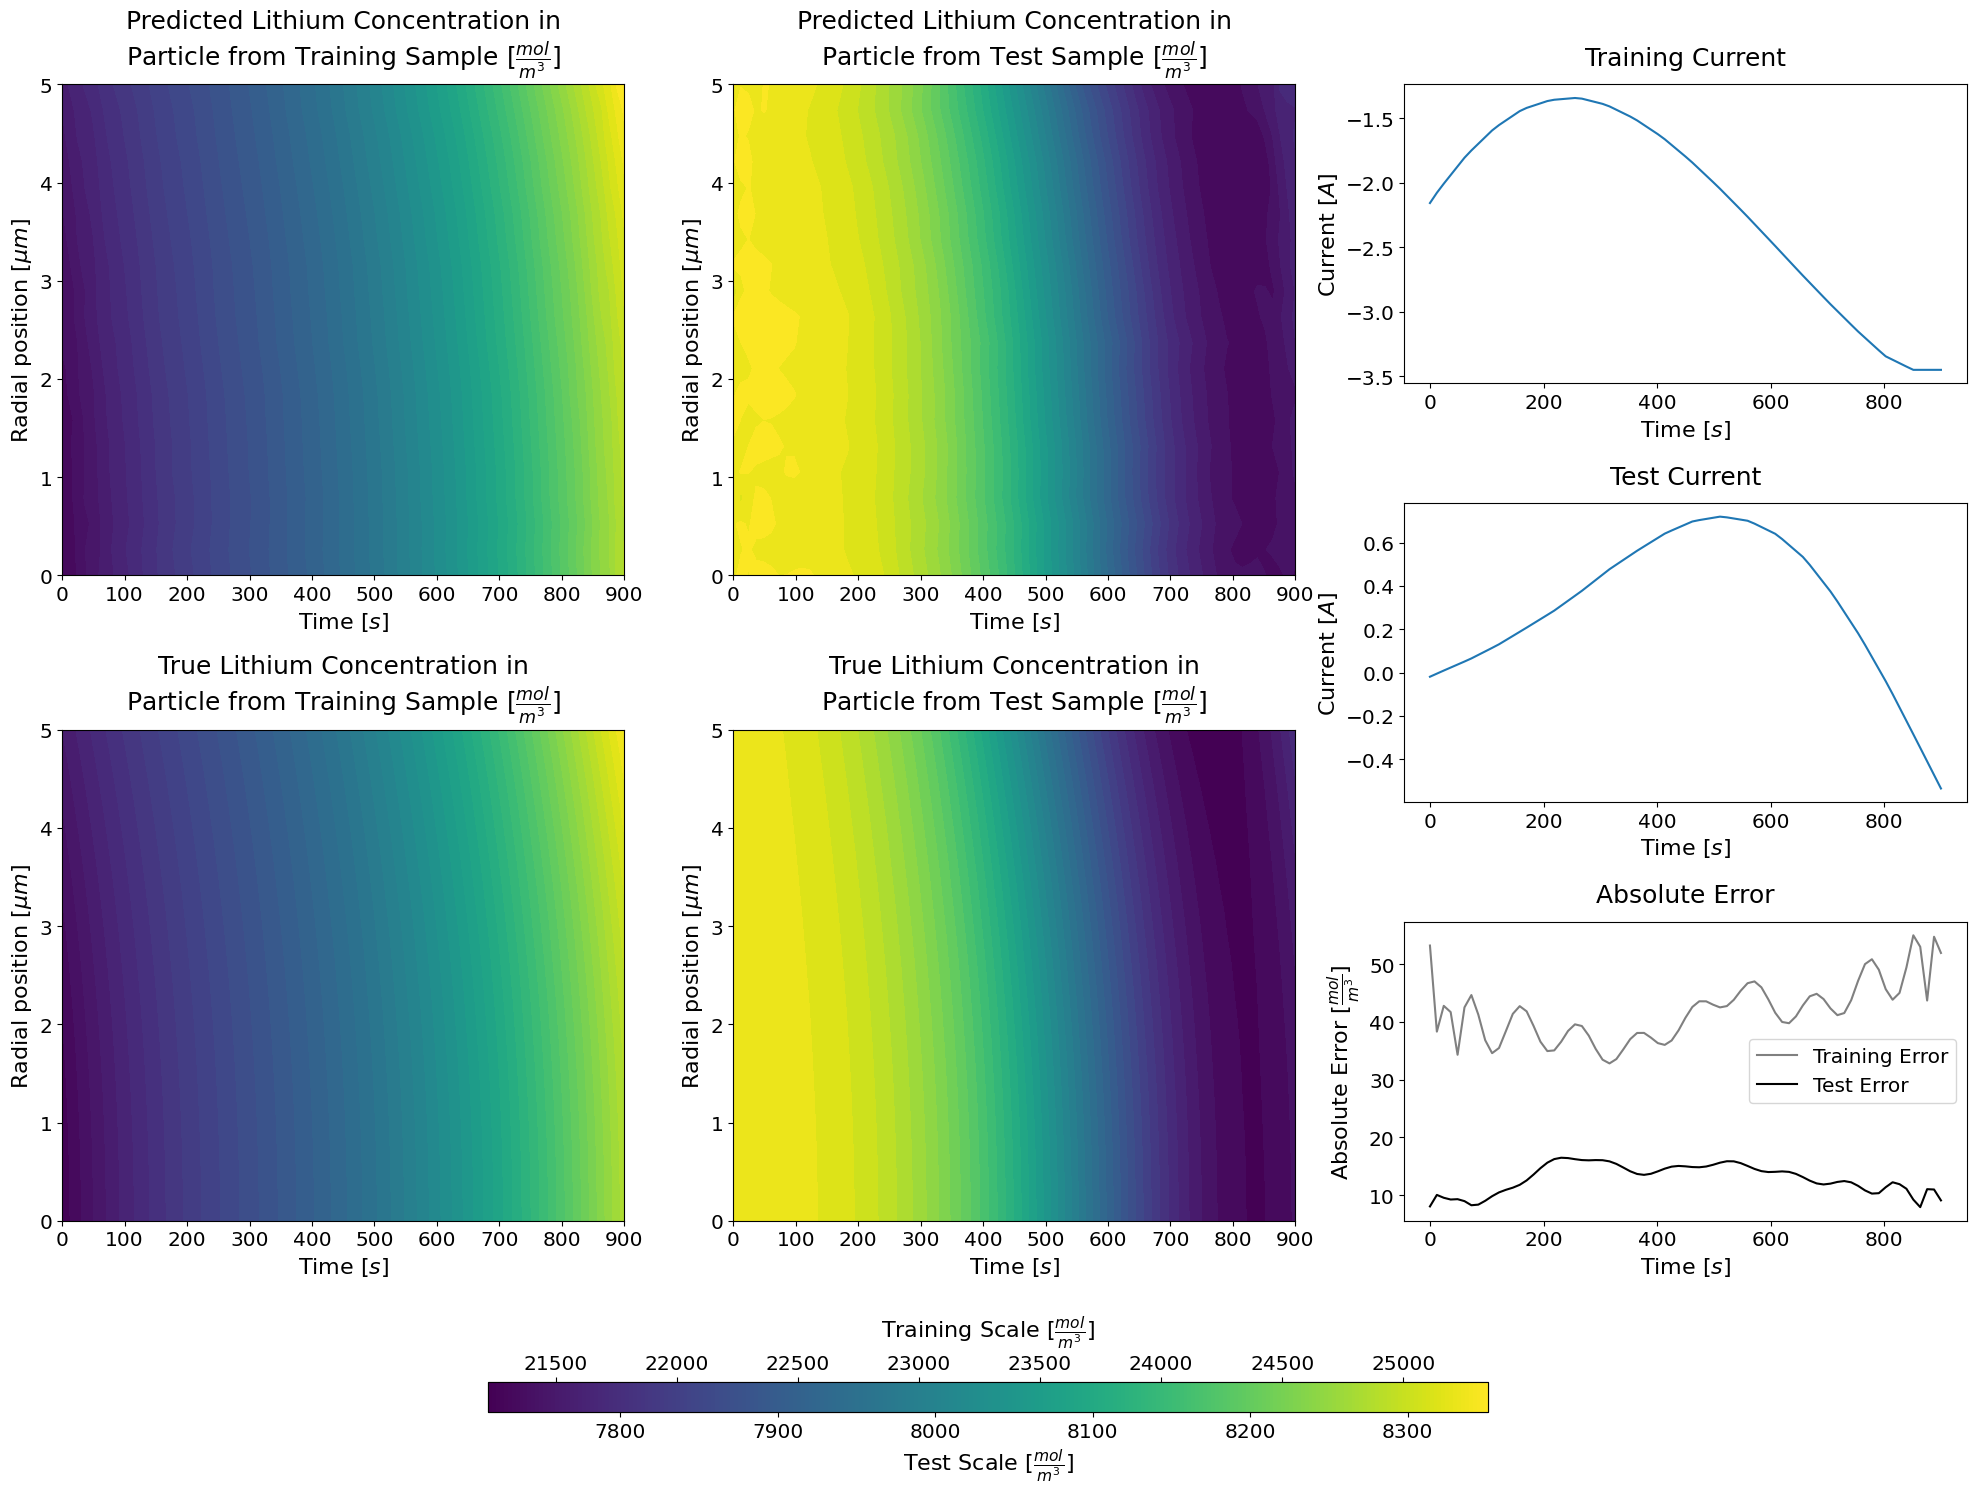

In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()